In [1]:
import numpy as np
import matplotlib.pyplot as plt

(-3.0, 13.0)

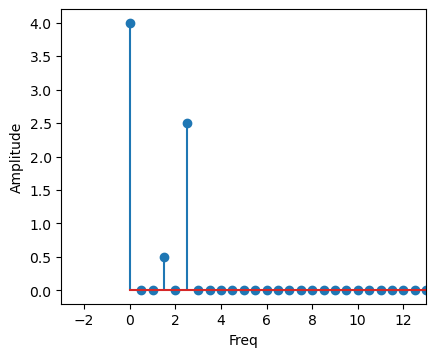

In [2]:
fs = 500
t = np.arange(0, 2, 1 / fs)

N = len(t)
signal = 2.5 * np.sin(2 * np.pi * 2.5 * t) + 0.5 * np.sin(2 * np.pi * 1.5 * t) + 2

fCoeffs = np.zeros((N,), dtype="complex")

fourierTime = np.arange(0, N) / N
for fi in range(N):
    csw = np.exp(-1j * 2 * np.pi * fi * fourierTime)

    fCoeffs[fi] = np.dot(csw, signal) / N

amps = 2 * np.abs(fCoeffs)
phases = np.angle(fCoeffs)

hz = np.linspace(0, fs//2, N//2 + 1)

plt.figure(figsize=(16, 13))
plt.subplot(331)
plt.stem(hz, amps[:N//2 + 1])
plt.xlabel("Freq")
plt.ylabel("Amplitude")
plt.xlim(-3, 13)

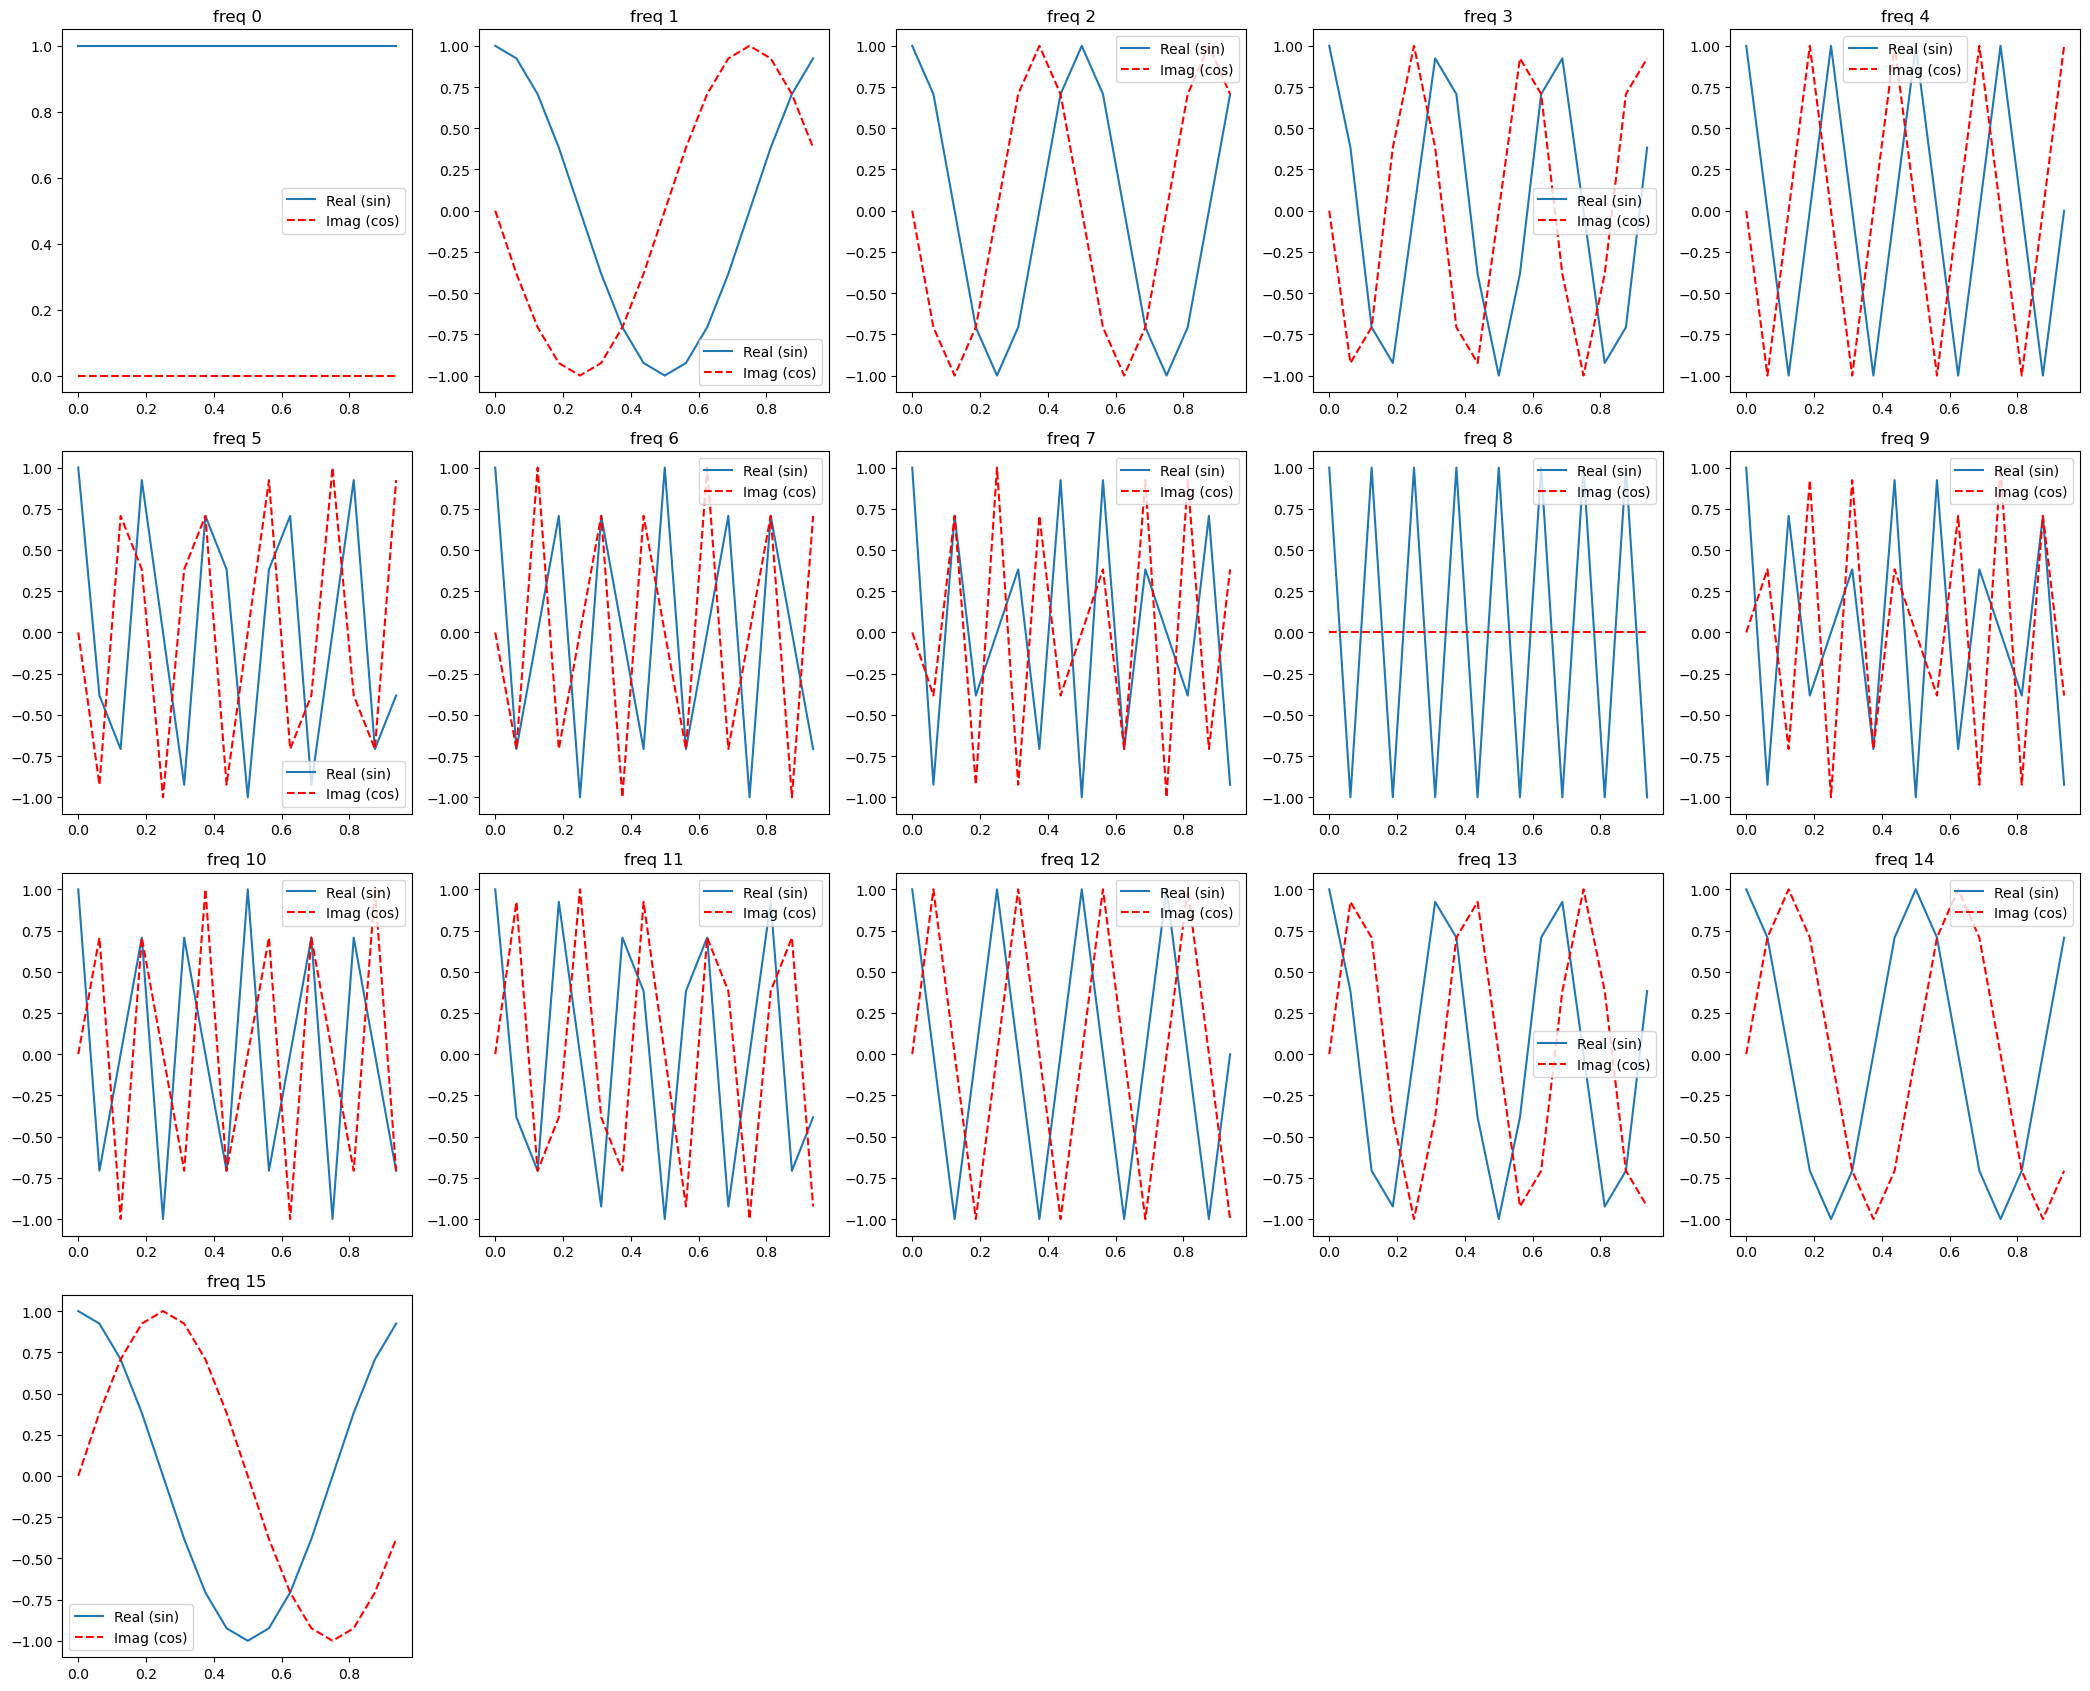

In [3]:
N = 16
fs = 500
fourierTime = np.arange(N) / N

plt.figure(figsize=(21, 21))
rows = 5
cols = 5

for fi in range(N):
    csw = np.exp(-1j * 2 * np.pi * fi * fourierTime)

    plt.subplot(rows, cols, fi + 1)
    plt.plot(fourierTime, np.real(csw), label="Real (sin)")
    plt.plot(fourierTime, np.imag(csw), 'r--', label="Imag (cos)")
    plt.title(f"freq {fi}")
    plt.legend()

plt.tight_layout()

In [4]:
# Nyquist guy
fs = 1000
N = 1000

nyq = fs // 2

hz_bad = np.linspace(0, nyq, N // 2 + 1)

if N % 2 != 0:
    nyq *= (N - 1) / N
    
hz_good = np.linspace(0, nyq, N // 2 + 1)

i = 39
print(hz_bad[i])
print(hz_good[i])
print(np.abs(hz_bad[i] - hz_good[i]))

len(hz_bad)

39.0
39.0
0.0


501

(-0.05, 50.0)

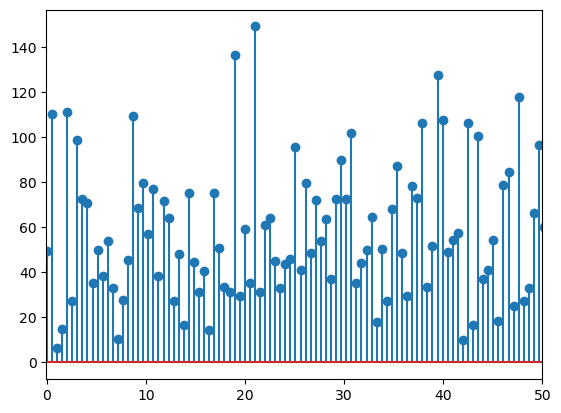

In [5]:
x = np.random.randn(1000)
fs = 512


plt.stem(np.linspace(0, fs // 2, len(x) // 2 + 1), 2 * np.abs(np.fft.fft(x))[: len(x) // 2 + 1])
plt.xlim(-0.05, 50)

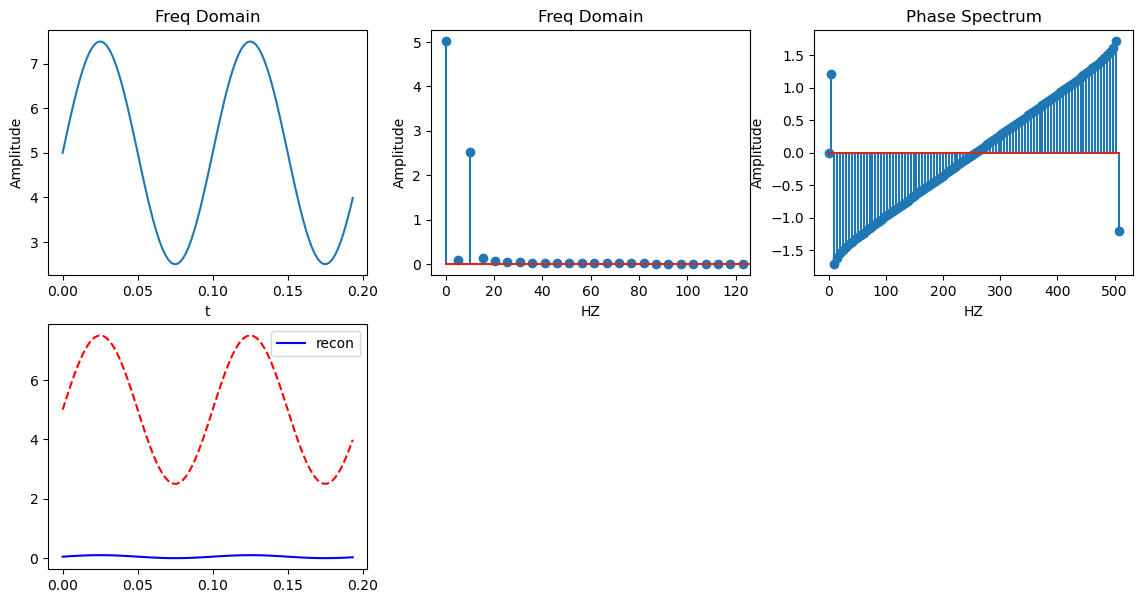

In [6]:
N = 100
fs = 512

t = np.arange(0, N) * 1 / fs
x = 2.5 * np.sin(2 * np.pi * 10 * t) + 5

fourierTime = np.arange(N) / N
freqs = np.arange(N) * fs/N

freq_vals = np.zeros((N,), dtype="complex")
for k in range(len(x)):
    csw = np.exp(-1j * 2 * np.pi * k * fourierTime)
    dot_prod = np.dot(csw, x)
    freq_vals[k] = dot_prod
    
freq_vals *= 2/N # why do i need this?!
freq_vals[0] /= 2

ifft = np.fft.ifft(freq_vals)

plt.figure(figsize=(14, 7))

plt.subplot(231)
plt.plot(t, x)
plt.title("Freq Domain")
plt.xlabel("t")
plt.ylabel("Amplitude")

plt.subplot(232)
plt.stem(freqs, np.abs(freq_vals))
plt.title("Freq Domain")
plt.xlabel("HZ")
plt.ylabel("Amplitude")
plt.xlim(-6, 126)

plt.subplot(233)
plt.stem(freqs, np.angle(freq_vals))
plt.title("Phase Spectrum")
plt.xlabel("HZ")
plt.ylabel("Amplitude")

plt.subplot(234)
plt.plot(t, np.real(ifft), 'b', label='recon')
plt.plot(t, x, 'r--')
plt.legend()

Text(0, 0.5, 'Amplitude')

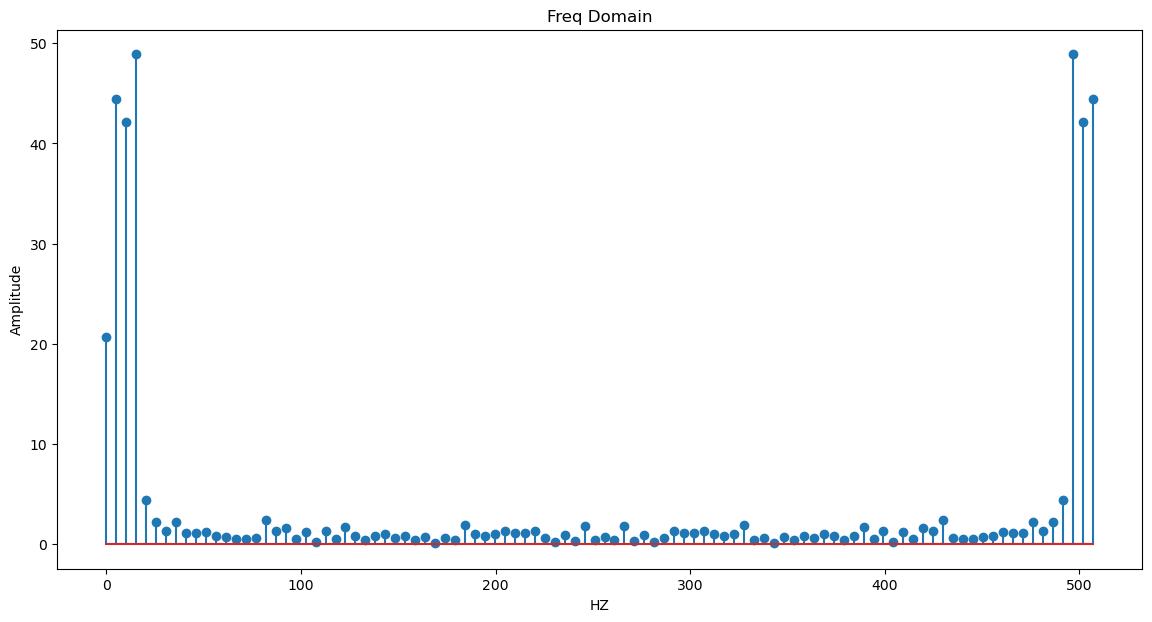

In [7]:
N = 100
fs = 512

t = np.arange(0, N) * 1 / fs
x = np.sin(2 * np.pi * 10 * t) + np.sin(2 * np.pi * 15 * t) + np.sin(2 * np.pi * 7 * t) + 0.1 * np.random.randn(N)

fourierTime = np.arange(N) / N
freqs = np.arange(N) * fs/N

freq_vals = np.zeros((N,), dtype="complex")
for k in range(len(x)):
    csw = np.exp(-1j * 2 * np.pi * k * fourierTime)
    dot_prod = np.dot(csw, x)
    freq_vals[k] = dot_prod

ifft = np.fft.ifft(freq_vals)

plt.figure(figsize=(14, 7))

plt.stem(freqs, np.abs(freq_vals))
plt.title("Freq Domain")
plt.xlabel("HZ")
plt.ylabel("Amplitude")



freq: 5.12


(-0.1, 10.0)

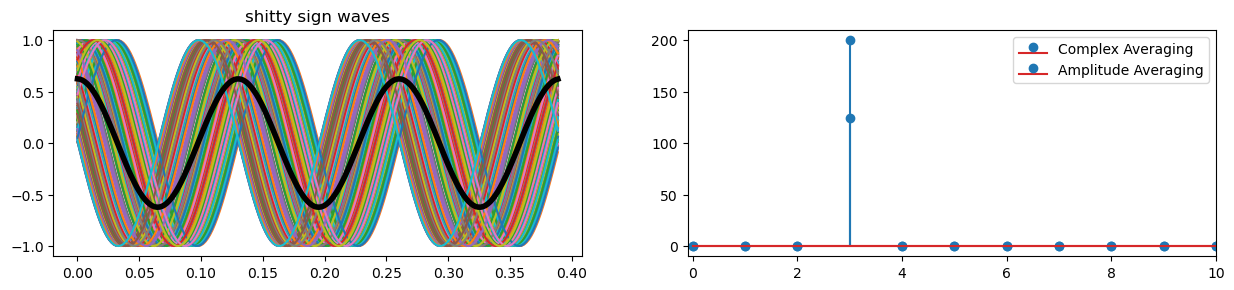

In [73]:
Ntrials = 300
Npnts = 200
fs = 512

sins = np.zeros((Ntrials, Npnts))

t = np.arange(Npnts) * 1 / fs
freq_multiplier = 1
for trial in range(Ntrials):
    sins[trial] = np.sin(freq_multiplier * fs/N * np.pi * t * 3 + np.random.uniform(0, 1 * np.pi))

print(f"freq: {freq_multiplier * fs/N}")
plt.figure(figsize=(15, 10))
rows, cols = 3, 2
plt.subplot(rows, cols, 1)
for sin in sins:
    plt.plot(t, sin)

avg_signal = np.mean(sins, axis=0)
plt.plot(t, avg_signal, "k", lw=4)
plt.title("shitty sign waves")


hz = np.arange(N) / N
Sins = np.fft.fft(sins)
Sins_avg_complex = np.abs(np.mean(Sins, axis=0)) * 2
Sins_avg_amplitude = np.mean(np.abs(Sins), axis=0) * 2

plt.subplot(rows, cols, 2)
plt.stem(Sins_avg_complex, label="Complex Averaging")
plt.stem(Sins_avg_amplitude, label="Amplitude Averaging")
plt.legend()
plt.xlim(-0.1, 10)